In [9]:
#Library
import pandas as pd
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [10]:
# --- PHASE 1: CONFIGURATION & HYPERPARAMETERS ---
AUDIO_PATH = "C:/Users/ErenYldzPC/Thesis_Study/VoiceDataStudy/audio"
CSV_PATH = "UrbanSound8K.csv"
BATCH_SIZE = 64        
LEARNING_RATE = 0.001  
EPOCHS = 30           
SAMPLE_RATE = 22050
DURATION = 4
N_MELS = 64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
# --- PHASE 2: DATA PIPELINE & FEATURE EXTRACTION ---
class UrbanSoundDataset(Dataset):
    """
    Custom Dataset class for audio feature extraction.
    Converts raw 1D signals into 2D Mel-Spectrogram representations.
    """
    def __init__(self, csv_file, fold_list):
        self.df = pd.read_csv(csv_file)
        self.data = self.df[self.df['fold'].isin(fold_list)].reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        file_path = os.path.join(AUDIO_PATH, f"fold{row['fold']}", row['slice_file_name'])
        
        try:
            # Audio loading and padding to ensure uniform temporal length
            audio, _ = librosa.load(file_path, sr=SAMPLE_RATE, duration=DURATION)
            if len(audio) < SAMPLE_RATE * DURATION:
                audio = np.pad(audio, (0, int(SAMPLE_RATE * DURATION - len(audio))))
            
            # Feature extraction via Mel-frequency Filterbanks
            mel = librosa.feature.melspectrogram(y=audio, sr=SAMPLE_RATE, n_mels=N_MELS)
            mel_db = librosa.power_to_db(mel, ref=np.max)
            return torch.tensor(mel_db).unsqueeze(0), torch.tensor(row['classID'])
        except Exception as e:
            # Error handling for corrupted audio files
            return torch.zeros((1, N_MELS, 173)), torch.tensor(row['classID'])

In [12]:
# --- PHASE 3: MODEL ARCHITECTURE & OBJECTIVE FUNCTIONS ---
class Audio2DCNN(nn.Module):
    """
    2D Convolutional Neural Network architecture optimized for spectrogram analysis.
    """
    def __init__(self, num_classes=10):
        super(Audio2DCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.dropout = nn.Dropout(0.3)
        # Linear layer dimensions calculated based on input resolution
        self.fc1 = nn.Linear(64 * (N_MELS // 4) * 43, 256) 
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

class FocalLoss(nn.Module):
    """
    Focal Loss implementation to mitigate class imbalance issues.
    """
    def __init__(self, gamma=2):
        super().__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        return ((1 - pt)**self.gamma * ce_loss).mean()

In [13]:
# --- PHASE 4: TRAINING & EVALUATION LOGIC ---
def run_experiment(loss_name, criterion, train_loader, val_loader):
    print(f"\n[EXECUTION] Starting Experiment: {loss_name}")
    model = Audio2DCNN().to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    history = {'train_loss': [], 'val_accuracy': []}
    
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            output = model(x)
            loss = criterion(output, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xv, yv in val_loader:
                xv, yv = xv.to(DEVICE), yv.to(DEVICE)
                out_v = model(xv)
                _, pred = torch.max(out_v, 1)
                total += yv.size(0)
                correct += (pred == yv).sum().item()
        
        val_acc = 100 * correct / total
        history['train_loss'].append(total_loss / len(train_loader))
        history['val_accuracy'].append(val_acc)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] Loss: {history['train_loss'][-1]:.4f} Val Acc: %{val_acc:.2f}")
            
    return model, history

In [14]:
# --- PHASE 5: VISUALIZATION & SCIENTIFIC REPORTING ---
def plot_results(all_results):
    plt.style.use('seaborn-v0_8')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for name, metrics in all_results.items():
        ax1.plot(metrics['train_loss'], label=name)
        ax2.plot(metrics['val_accuracy'], label=name)
    
    ax1.set_title('Training Loss Convergence')
    ax1.set_xlabel('Epochs'); ax1.set_ylabel('Loss')
    ax1.legend(); ax1.grid(True)
    
    ax2.set_title('Validation Accuracy Progress')
    ax2.set_xlabel('Epochs'); ax2.set_ylabel('Accuracy (%)')
    ax2.legend(); ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

def final_evaluation(model, test_loader, name):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xt, yt in test_loader:
            xt = xt.to(DEVICE)
            out = model(xt)
            _, p = torch.max(out, 1)
            y_true.extend(yt.tolist())
            y_pred.extend(p.tolist())
    
    print(f"\n[RESULT] Final Test Report for {name}:")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()


[EXECUTION] Starting Experiment: CrossEntropy
Epoch [5/30] Loss: 0.4111 Val Acc: %61.15
Epoch [10/30] Loss: 0.1722 Val Acc: %63.24
Epoch [15/30] Loss: 0.1508 Val Acc: %66.79
Epoch [20/30] Loss: 0.0968 Val Acc: %63.11
Epoch [25/30] Loss: 0.0607 Val Acc: %66.79
Epoch [30/30] Loss: 0.1390 Val Acc: %63.85

[RESULT] Final Test Report for CrossEntropy:
              precision    recall  f1-score   support

           0       0.81      0.72      0.76       100
           1       0.93      0.82      0.87        33
           2       0.57      0.45      0.50       100
           3       0.75      0.71      0.73       100
           4       0.56      0.77      0.65       100
           5       0.65      0.54      0.59        93
           6       0.94      1.00      0.97        32
           7       0.72      0.70      0.71        96
           8       0.56      0.58      0.57        83
           9       0.66      0.77      0.71       100

    accuracy                           0.68       837


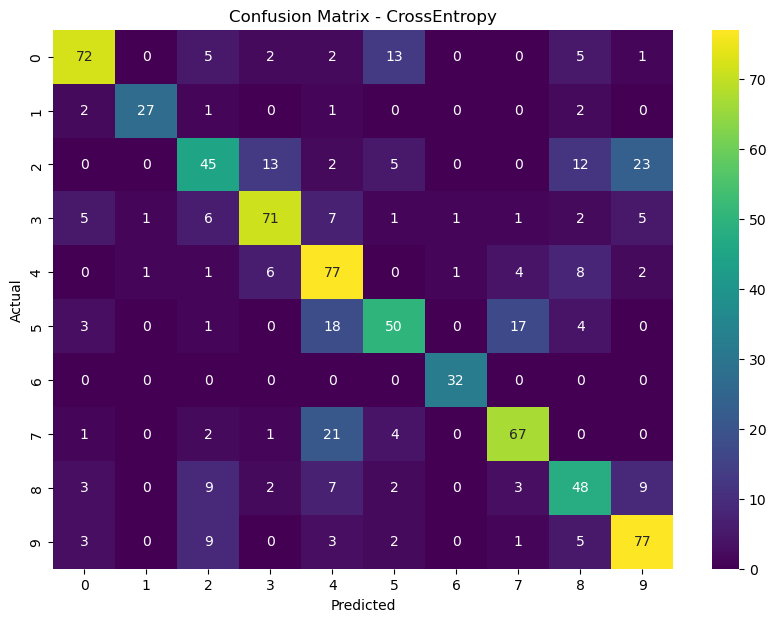


[EXECUTION] Starting Experiment: FocalLoss
Epoch [5/30] Loss: 0.6861 Val Acc: %65.56
Epoch [10/30] Loss: 0.3998 Val Acc: %63.11
Epoch [15/30] Loss: 0.2864 Val Acc: %64.95
Epoch [20/30] Loss: 0.1826 Val Acc: %63.48
Epoch [25/30] Loss: 0.1412 Val Acc: %64.71
Epoch [30/30] Loss: 0.1175 Val Acc: %67.77

[RESULT] Final Test Report for FocalLoss:
              precision    recall  f1-score   support

           0       0.75      0.67      0.71       100
           1       0.81      0.67      0.73        33
           2       0.52      0.65      0.58       100
           3       0.78      0.70      0.74       100
           4       0.46      0.57      0.51       100
           5       0.66      0.55      0.60        93
           6       0.94      1.00      0.97        32
           7       0.76      0.81      0.79        96
           8       0.81      0.52      0.63        83
           9       0.56      0.64      0.60       100

    accuracy                           0.66       837
   mac

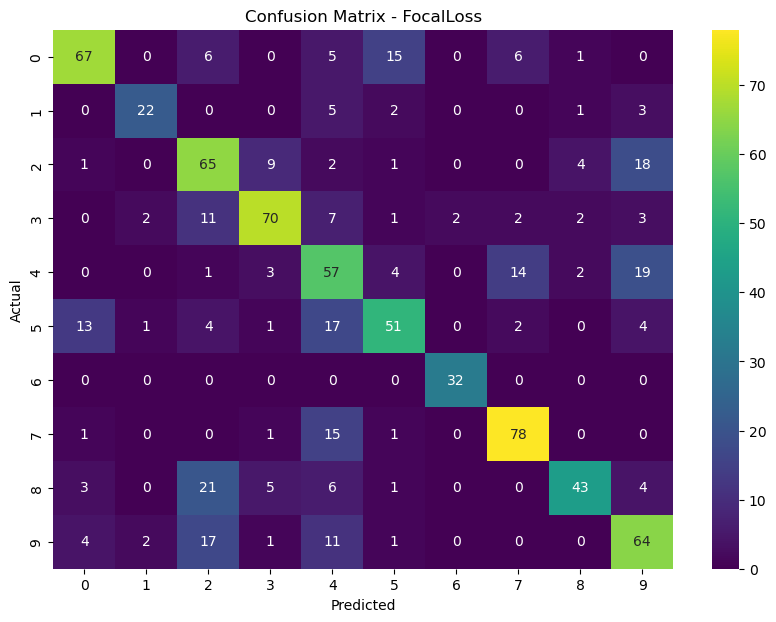


[EXECUTION] Starting Experiment: LabelSmoothing
Epoch [5/30] Loss: 0.7498 Val Acc: %66.79
Epoch [10/30] Loss: 0.6166 Val Acc: %68.87
Epoch [15/30] Loss: 0.5799 Val Acc: %66.79
Epoch [20/30] Loss: 0.5721 Val Acc: %67.40
Epoch [25/30] Loss: 0.5628 Val Acc: %66.54
Epoch [30/30] Loss: 0.5602 Val Acc: %67.28

[RESULT] Final Test Report for LabelSmoothing:
              precision    recall  f1-score   support

           0       0.59      0.59      0.59       100
           1       0.90      0.85      0.88        33
           2       0.55      0.66      0.60       100
           3       0.88      0.68      0.77       100
           4       0.51      0.82      0.63       100
           5       0.71      0.61      0.66        93
           6       0.97      1.00      0.98        32
           7       0.64      0.65      0.64        96
           8       0.75      0.53      0.62        83
           9       0.81      0.63      0.71       100

    accuracy                           0.67       

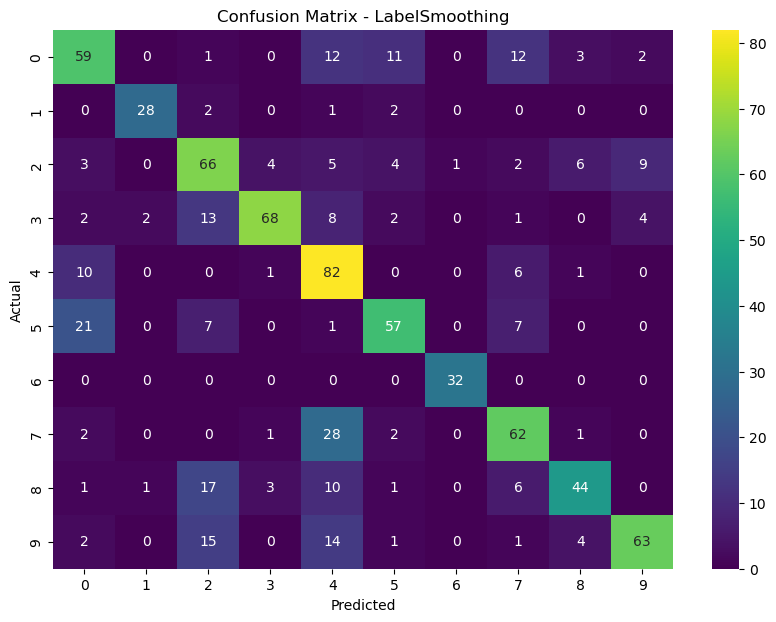

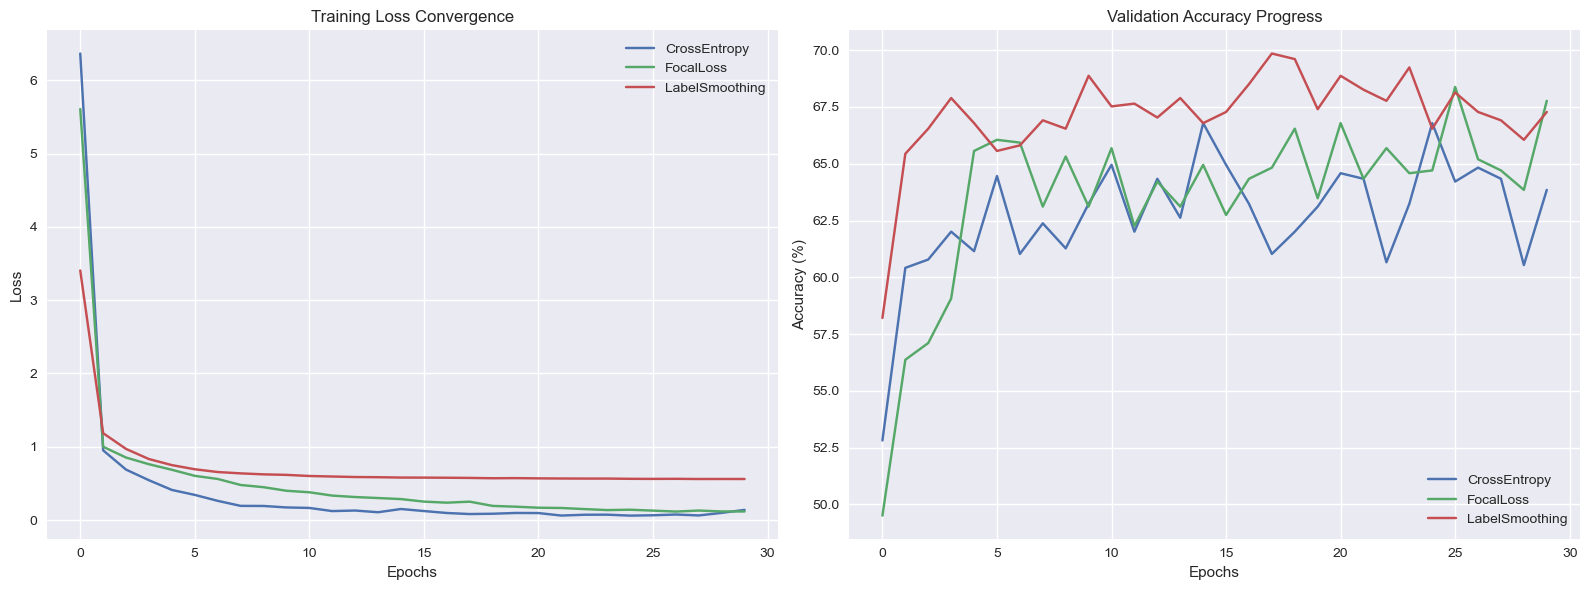

In [15]:
# --- MAIN EXECUTION ---
if __name__ == "__main__":
    # Data Folding Strategy
    train_loader = DataLoader(UrbanSoundDataset(CSV_PATH, [1,2,3,4,5,6,7,8]), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(UrbanSoundDataset(CSV_PATH, [9]), batch_size=BATCH_SIZE)
    test_loader = DataLoader(UrbanSoundDataset(CSV_PATH, [10]), batch_size=BATCH_SIZE)

    experiments = {
        "CrossEntropy": nn.CrossEntropyLoss(),
        "FocalLoss": FocalLoss(gamma=2),
        "LabelSmoothing": nn.CrossEntropyLoss(label_smoothing=0.1)
    }

    results_data = {}
    for name, crit in experiments.items():
        trained_model, metrics = run_experiment(name, crit, train_loader, val_loader)
        results_data[name] = metrics
        final_evaluation(trained_model, test_loader, name)
    
    plot_results(results_data)